# Day 14 and Day 22
Notebook containing solutions for made for day 14 and 22, both missing formatting and comments. They are kept in the notebook as they were made in one, and they have not  been moved to regular Python files yet. The second part of day 14 takes also too much time to compute, although it can be easily made more efficient.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import enum
from ast import literal_eval


USE_EXAMPLE_FILES = True
# USE_EXAMPLE_FILES = False

example_file_names = ["puzzleInputs/day" + str(idx) + "_example.txt" for idx in range(1,26)]
base_file_names = ["puzzleInputs/day" + str(idx) + ".txt" for idx in range(1,26)]
if(USE_EXAMPLE_FILES == True):
    file_names = example_file_names
else:
    file_names = base_file_names

# [Day 14: Regolith Reservoir](https://adventofcode.com/2022/day/14)
**First Part:** Calculate how many units of sand fell until one of them flows into the abyss

**Second Part:** Calculate how many units of sand fell until they block their own source

In [2]:
SAND_SOURCE_POSITION = [500,0]

with open(file_names[13]) as f:
    lines14 = f.read().splitlines()
    while(lines14[-1] == ""): # remove last empty lines, if any. They do not add information and can cause confusion
        lines14.pop()

# TODO improve the parsing, some elements are repeated

blocked_nodes = []
for line in lines14:
    path_nodes = line.split(" -> ")

    path_begin = [int(x) for x in path_nodes[0].split(",")]
    for path_end_string in path_nodes[1:]:
        path_end = [int(x) for x in path_end_string.split(",")]

        if(path_begin[0] == path_end[0]):
            sorted_begin, sorted_end  = np.sort([path_begin[1],path_end[1]])
            for idx in range(sorted_begin,sorted_end+1):
                blocked_nodes.append([path_begin[0],idx])
        else:
            sorted_begin, sorted_end  = np.sort([path_begin[0],path_end[0]])
            for idx in range(sorted_begin,sorted_end+1):
                blocked_nodes.append([idx,path_begin[1]])

        path_begin = path_end


lower_border = max([node[1] for node in blocked_nodes]) # after this border, the sand fells into the abyss

stacked_sand = 0
end_superior_loop = False
while(end_superior_loop == False):
    sand_position = SAND_SOURCE_POSITION

    sand_has_stacked = False
    while(sand_has_stacked == False):
    # vertical drop
        if( [sand_position[0], sand_position[1] +1] in blocked_nodes):

            # left diagonal
            if( [sand_position[0]-1, sand_position[1] +1] in blocked_nodes):

                # right diagonal
                if( [sand_position[0]+1, sand_position[1]+1] in blocked_nodes):

                    blocked_nodes.append(sand_position)
                    sand_has_stacked = True
                            
                else:
                    sand_position = [sand_position[0]+1, sand_position[1]+1]
            else:
                sand_position = [sand_position[0]-1, sand_position[1]+1]
                
        else:
            sand_position = [sand_position[0], sand_position[1]+1]

        if(sand_position[1] > lower_border):
            end_superior_loop = True
            break

    if(end_superior_loop == False):
        stacked_sand += 1
        
print("The amount of stacked sand before some fells into the abyss is", stacked_sand)

The amount of stacked sand before some fells into the abyss is 24


In [3]:
''' 
This is very slow, taking around an hour to compute. It is basically the same code as Part 1

It is possible to do a smarter version of this program, by calculating the amount of sand that could be placed if there was nothing blocking it, and then subtracting it the amount of spaces that cannot hold any sand, because they are blocked or covered by rocks

TODO: Change this program almost completely
'''

blocked_nodes_temp = np.array(blocked_nodes)
lower_border = np.max(blocked_nodes_temp[:,1]) + 2
# rightmost_border = 


stacked_sand = 0
end_superior_loop = False
while(end_superior_loop == False):
    sand_position = SAND_SOURCE_POSITION

    sand_has_stacked = False
    while(sand_has_stacked == False):
    # vertical drop
        if( (sand_position[1] +1) == lower_border):
            blocked_nodes.append(sand_position)
            sand_has_stacked = True
        elif( [sand_position[0], sand_position[1] +1] in blocked_nodes):

            # left diagonal
            if( [sand_position[0]-1, sand_position[1] +1] in blocked_nodes):

                # right diagonal
                if( [sand_position[0]+1, sand_position[1]+1] in blocked_nodes):
                    
                    if(sand_position == SAND_SOURCE_POSITION):
                        end_superior_loop = True
                        break
                    else:
                        blocked_nodes.append(sand_position)
                        sand_has_stacked = True
                            
                else:
                    sand_position = [sand_position[0]+1, sand_position[1]+1]
            else:
                sand_position = [sand_position[0]-1, sand_position[1]+1]
                
        else:
            sand_position = [sand_position[0], sand_position[1]+1]
            
    stacked_sand += 1

print("The amount of stacked sand before blocking their source is", stacked_sand)

The amount of stacked sand before blocking their source is 69


# [Day 22: Monkey Map](https://adventofcode.com/2022/day/22)
**First Part:** Follow the given path, taking into account wrapping rules

**Second Part:** Follow the given path, taking into account new 3D wrapping rules


In [4]:
class Orientation(enum.IntEnum):
    LOWER_LIMIT = -1
    RIGHT = 0
    DOWN = 1
    LEFT = 2
    UP = 3
    UPPER_LIMIT = 4


NO_PATH = " "
SOLID_WALL = "#"
OPEN_TILE = "."
CLOCKWISE_INSTRUCTION = "R"
COUNTERCLOCKWISE_INSTRUCTION = "L"


with open(file_names[21]) as file:
    stacked_lines = file.read()
    lines22 = stacked_lines.splitlines()
    while(lines22[-1] == ""): # remove last empty lines, if any. They do not add information and can cause confusion
        lines22.pop()



steps_instructions = lines22[-1]
maze = lines22[:-2]
n_rows = len(maze)
n_cols = 0
for line in maze:
    possible_n_cols = len(line)
    if(possible_n_cols > n_cols):
        n_cols = possible_n_cols

wrap_points_correspondences_col_right = {}
wrap_points_correspondences_col_left = {}
blocked_paths = []

for row_n in range(n_rows):
    n_cols_in_row = len(maze[row_n])

    if(maze[row_n][0] == NO_PATH):
        possible_wrap_col = -1
    elif(maze[row_n][0] == SOLID_WALL):
        blocked_paths.append([row_n,0])
        possible_wrap_col = 0
    else:
        possible_wrap_col = 0

    for col_n in range(1,n_cols_in_row-1):
        
        if(maze[row_n][col_n] == NO_PATH):
            continue
        
        else:
            if(maze[row_n][col_n] == SOLID_WALL):
                blocked_paths.append([row_n,col_n])
                
            if(possible_wrap_col == -1):
                possible_wrap_col = col_n

    if(maze[row_n][n_cols_in_row-1] == SOLID_WALL):
        blocked_paths.append([row_n,n_cols_in_row-1])
    
    wrap_points_correspondences_col_left[str([row_n,possible_wrap_col])] = [row_n,n_cols_in_row-1]
    wrap_points_correspondences_col_right[str([row_n,n_cols_in_row-1])] = [row_n,possible_wrap_col]


wrap_points_correspondences_row_up = {}
wrap_points_correspondences_row_down = {}
for col_n in range(n_cols):

    if(col_n >= len(maze[0])):
        possible_wrap_row = -1
        beginning_has_been_found = False
    elif(maze[0][col_n] == NO_PATH):
        possible_wrap_row = -1
        beginning_has_been_found = False
    elif(maze[0][col_n] == SOLID_WALL):
        blocked_paths.append([0,col_n])
        possible_wrap_row = 0
        beginning_has_been_found = True
    else:
        possible_wrap_row = 0
        beginning_has_been_found = True

    for row_n in range(1,n_rows):

        if(col_n >= len(maze[row_n])):
            if(beginning_has_been_found == True):
                if(maze[row_n-1][col_n] == SOLID_WALL):
                    blocked_paths.append([row_n-1,col_n])
          
                wrap_points_correspondences_row_down[str([row_n-1,col_n])] = [possible_wrap_row,col_n]
                wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n-1,col_n]
                possible_wrap_row = -1
                beginning_has_been_found = False
                break
            else:
                continue

        if(maze[row_n][col_n] == NO_PATH):

            if(beginning_has_been_found == True):
                if(maze[row_n-1][col_n] == SOLID_WALL):
                    blocked_paths.append([row_n-1,col_n])
          
                wrap_points_correspondences_row_down[str([row_n-1,col_n])] = [possible_wrap_row,col_n]
                wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n-1,col_n]
                possible_wrap_row = -1
                break
            
        
        else:
            if(maze[row_n][col_n] == SOLID_WALL):
                blocked_paths.append([row_n,col_n])
                
            if(beginning_has_been_found == False and possible_wrap_row == -1):
                    possible_wrap_row = row_n
                    beginning_has_been_found = True
        
        

    if(possible_wrap_row != -1):
        wrap_points_correspondences_row_down[str([row_n,col_n])] = [possible_wrap_row,col_n]
        wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n,col_n]


maze_map = np.zeros([n_rows,n_cols]) # variable only used to keep track of the path in order to plot it
next_orientation = Orientation.RIGHT
position = [0, maze[0].find(OPEN_TILE)]
end_following_path = False
while(end_following_path == False):
    current_orientation = next_orientation

    clockwise_instruction_pos = steps_instructions.find(CLOCKWISE_INSTRUCTION)
    counterclockwise_instruction_pos = steps_instructions.find(COUNTERCLOCKWISE_INSTRUCTION)

    if(counterclockwise_instruction_pos == -1 and clockwise_instruction_pos == -1):
        end_following_path = True
        n_steps = int(steps_instructions)
        next_orientation = current_orientation
    else:
        if(counterclockwise_instruction_pos == -1):
            counterclockwise_instruction_pos = clockwise_instruction_pos + 1 # force it to fulfill the conditions below
        elif(clockwise_instruction_pos == -1):
            clockwise_instruction_pos = counterclockwise_instruction_pos + 1 # force it to fulfill the conditions below

        if(clockwise_instruction_pos < counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:clockwise_instruction_pos])
            steps_instructions = steps_instructions[clockwise_instruction_pos+1:]
            next_orientation = current_orientation + 1

        elif(clockwise_instruction_pos > counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:counterclockwise_instruction_pos])
            steps_instructions = steps_instructions[counterclockwise_instruction_pos+1:]
            next_orientation = current_orientation - 1

    possible_next_position = position.copy()
    if(current_orientation == Orientation.UP):
        for _ in range(n_steps):
            possible_next_position[0] -= 1
            if(str(position) in wrap_points_correspondences_row_up):
                possible_next_position = wrap_points_correspondences_row_up[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.RIGHT):
        for _ in range(n_steps):
            possible_next_position[1] += 1
            if(str(position) in wrap_points_correspondences_col_right):
                possible_next_position = wrap_points_correspondences_col_right[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.DOWN):
        for _ in range(n_steps):
            possible_next_position[0] += 1
            if(str(position) in wrap_points_correspondences_row_down):
                possible_next_position = wrap_points_correspondences_row_down[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.LEFT):
        for _ in range(n_steps):
            possible_next_position[1] -= 1
            if(str(position) in wrap_points_correspondences_col_left):
                possible_next_position = wrap_points_correspondences_col_left[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    
    if(next_orientation == Orientation.LOWER_LIMIT):
        next_orientation = Orientation.UPPER_LIMIT - 1
    elif(next_orientation == Orientation.UPPER_LIMIT):
        next_orientation = Orientation.LOWER_LIMIT + 1



position_1_based = position.copy()
position_1_based[0] += 1
position_1_based[1] += 1
password = 1000*position_1_based[0] + position_1_based[1]*4 + current_orientation
print("The final position is row {}, column {} and oriented {}, which gives the password {}".format(position_1_based[0], position_1_based[1], Orientation(current_orientation).name.lower(), password) )

The final position is row 6, column 8 and oriented right, which gives the password 6032


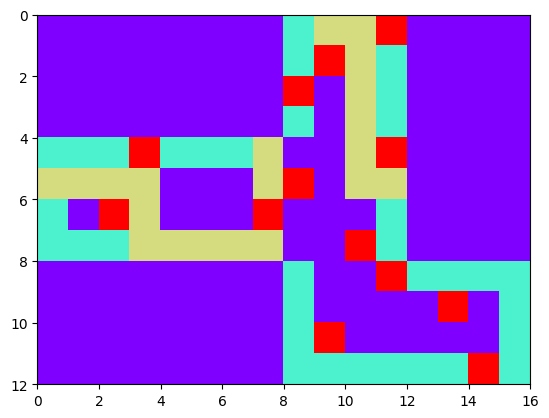

In [5]:
# TODO make the colors nicer, although it looks decent when using the non-example input file

# the evals are used to avoid parsing the string
maze_map_to_plot = maze_map.copy()
for wrap_point in wrap_points_correspondences_col_right.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_down.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_col_left.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_up.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for blocked_cell in blocked_paths:
    maze_map_to_plot[tuple(blocked_cell)] = 15
    
plt.imshow(maze_map_to_plot, cmap="rainbow", extent=[0,n_cols,n_rows,0]); # it is more practical to use a imshow than to show text, as the input that is not from the example is really long. It could be nice to have the text file scaled and displayed

In [6]:
'''
This cell maintained the same structure as the previous part, with some notation improvements. Now, the wrapping point variables are expanded to cover all sides of the cube. However, these variables that determine the wrapping points of the cube are harcoded for both available files. TODO think of a general code that could assign those wrapping points automatically, the example file and the non-example file gave different cube structures
'''

wrap_points_correspondences_right = {}
wrap_points_correspondences_left = {}
wrap_points_correspondences_up = {}
wrap_points_correspondences_down = {}
wrap_points_orientations_right = {}
wrap_points_orientations_left = {}
wrap_points_orientations_up = {}
wrap_points_orientations_down = {}

if(len(lines22) == 14): # if it is the example file
    CUBE_DIMENSIONS = 4

    # first row of cubes
    col_begin = CUBE_DIMENSIONS*2
    row_begin = 0
    row_dest = CUBE_DIMENSIONS
    col_dest = CUBE_DIMENSIONS
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest + movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination 
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    col_begin = CUBE_DIMENSIONS*3-1
    row_begin = 0
    row_dest = CUBE_DIMENSIONS*4 - 1
    col_dest = CUBE_DIMENSIONS*3 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest - movement_step, col_dest] # appears right
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_left[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.LEFT
        wrap_points_orientations_left[str(destination)] = Orientation.LEFT


    # second row of cubes 
    col_begin = 0
    row_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = CUBE_DIMENSIONS*4-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears down
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.RIGHT

    col_begin = CUBE_DIMENSIONS*3-1
    row_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*2
    col_dest = CUBE_DIMENSIONS*4 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.LEFT


    # third row of cubes (only leftmost)
    col_begin = CUBE_DIMENSIONS*2
    row_begin = CUBE_DIMENSIONS*2
    row_dest = CUBE_DIMENSIONS*2-1
    col_dest = CUBE_DIMENSIONS*2-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears down
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.RIGHT

    # first column of cubes
    col_begin = 0
    row_begin = CUBE_DIMENSIONS
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*3-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes top
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_up[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_up[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.DOWN

    col_begin = 0
    row_begin = CUBE_DIMENSIONS*2-1
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = CUBE_DIMENSIONS*3-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes bottom
        destination = [row_dest, col_dest - movement_step] # appears bottom
        wrap_points_correspondences_down[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_down[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.UP



else: 
    CUBE_DIMENSIONS = 50

    # first row of cubes
    row_begin = 0
    col_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = 0
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest - movement_step, col_dest] # appears left
        wrap_points_correspondences_left[str(incoming)] = destination 
        wrap_points_correspondences_left[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.RIGHT
        wrap_points_orientations_left[str(destination)] = Orientation.RIGHT

    row_begin = 0
    col_begin = CUBE_DIMENSIONS*3-1
    row_dest = CUBE_DIMENSIONS*3 - 1
    col_dest = CUBE_DIMENSIONS*2 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest - movement_step, col_dest] # appears right
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_right[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.LEFT
        wrap_points_orientations_right[str(destination)] = Orientation.LEFT

    # second row of cubes
    row_begin = CUBE_DIMENSIONS
    col_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*2
    col_dest = 0
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest + movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    row_begin = CUBE_DIMENSIONS
    col_begin = CUBE_DIMENSIONS*2-1
    row_dest = CUBE_DIMENSIONS - 1
    col_dest = CUBE_DIMENSIONS*2
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest + movement_step] # appears down
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.LEFT

    
    # fourth row of cubes
    row_begin = CUBE_DIMENSIONS*3
    col_begin = 0
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*2 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    row_begin = CUBE_DIMENSIONS*3
    col_begin = CUBE_DIMENSIONS - 1
    row_dest = CUBE_DIMENSIONS*3 - 1
    col_dest = CUBE_DIMENSIONS
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest + movement_step] # appears down
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.LEFT


    # first column of cubes
    row_begin = CUBE_DIMENSIONS*4-1
    col_begin = 0
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*2
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes down
        destination = [row_dest, col_dest + movement_step] # appears up
        wrap_points_correspondences_down[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_down[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.UP


steps_instructions = lines22[-1]
maze = lines22[:-2]
n_rows = len(maze)
n_cols = 0
for line in maze:
    possible_n_cols = len(line)
    if(possible_n_cols > n_cols):
        n_cols = possible_n_cols

blocked_paths = []
for row_n in range(n_rows):
    n_cols_in_row = len(maze[row_n])
    
    wrapping_point_assigned = False
    for col_n in range(n_cols_in_row):
        
        if(maze[row_n][col_n] == SOLID_WALL):
            blocked_paths.append([row_n,col_n])
    
    

for col_n in range(n_cols):
    for row_n in range(1,n_rows):

        if(col_n >= len(maze[row_n])):
            continue

        if(maze[row_n][col_n] == SOLID_WALL):
            blocked_paths.append([row_n,col_n])
            beginning_has_been_found = True

possible_steps = [0]*Orientation.UPPER_LIMIT
possible_steps[Orientation.RIGHT] = [0,1]
possible_steps[Orientation.DOWN] = [1,0]
possible_steps[Orientation.LEFT] = [0,-1]
possible_steps[Orientation.UP] = [-1,0]

wrap_points_correspondences = [0]*Orientation.UPPER_LIMIT
wrap_points_correspondences[Orientation.RIGHT] = wrap_points_correspondences_right
wrap_points_correspondences[Orientation.DOWN] = wrap_points_correspondences_down
wrap_points_correspondences[Orientation.LEFT] = wrap_points_correspondences_left
wrap_points_correspondences[Orientation.UP] = wrap_points_correspondences_up

wrap_points_orientations = [0]*Orientation.UPPER_LIMIT
wrap_points_orientations[Orientation.RIGHT] = wrap_points_orientations_right
wrap_points_orientations[Orientation.DOWN] = wrap_points_orientations_down
wrap_points_orientations[Orientation.LEFT] = wrap_points_orientations_left
wrap_points_orientations[Orientation.UP] = wrap_points_orientations_up



maze_map = np.zeros([n_rows,n_cols]) # variable only used to keep track of the path in order to plot it
next_orientation = Orientation.RIGHT
position = [0, maze[0].find(OPEN_TILE)]
end_following_path = False
while(end_following_path == False):
    current_orientation = next_orientation

    clockwise_instruction_pos = steps_instructions.find(CLOCKWISE_INSTRUCTION)
    counterclockwise_instruction_pos = steps_instructions.find(COUNTERCLOCKWISE_INSTRUCTION)

    if(counterclockwise_instruction_pos == -1 and clockwise_instruction_pos == -1):
        end_following_path = True
        n_steps = int(steps_instructions)
        next_orientation = current_orientation
        orientation_step = 0
    else:
        if(counterclockwise_instruction_pos == -1):
            counterclockwise_instruction_pos = clockwise_instruction_pos + 1 # force it to fulfill the conditions below
        elif(clockwise_instruction_pos == -1):
            clockwise_instruction_pos = counterclockwise_instruction_pos + 1 # force it to fulfill the conditions below

        if(clockwise_instruction_pos < counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:clockwise_instruction_pos])
            steps_instructions = steps_instructions[clockwise_instruction_pos+1:]
            orientation_step = 1

        elif(clockwise_instruction_pos > counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:counterclockwise_instruction_pos])
            steps_instructions = steps_instructions[counterclockwise_instruction_pos+1:]
            orientation_step = -1

    possible_next_position = position.copy()
    possible_current_orientation = current_orientation
    step = possible_steps[current_orientation]
    for _ in range(n_steps):
        possible_next_position[0] += step[0]
        possible_next_position[1] += step[1]
        if(str(position) in wrap_points_correspondences[current_orientation]):
            possible_next_position = wrap_points_correspondences[current_orientation][str(position)].copy()
            possible_current_orientation = wrap_points_orientations[current_orientation][str(position)]
            step = possible_steps[possible_current_orientation]
            
        if(possible_next_position not in blocked_paths):
            position = possible_next_position.copy()
            current_orientation = possible_current_orientation
            maze_map[tuple(position)] = 10
        else:
            break

    
    next_orientation = Orientation(current_orientation + orientation_step)
    if(next_orientation == Orientation.LOWER_LIMIT):
        next_orientation = Orientation(Orientation.UPPER_LIMIT - 1)
    elif(next_orientation == Orientation.UPPER_LIMIT):
        next_orientation = Orientation(Orientation.LOWER_LIMIT + 1)



position_1_based = position.copy()
position_1_based[0] += 1
position_1_based[1] += 1
password = 1000*position_1_based[0] + position_1_based[1]*4 + current_orientation
print("The final position is row {}, column {} and oriented {}, which gives the password {}".format(position_1_based[0], position_1_based[1], Orientation(current_orientation).name.lower(), password) )

The final position is row 5, column 7 and oriented up, which gives the password 5031


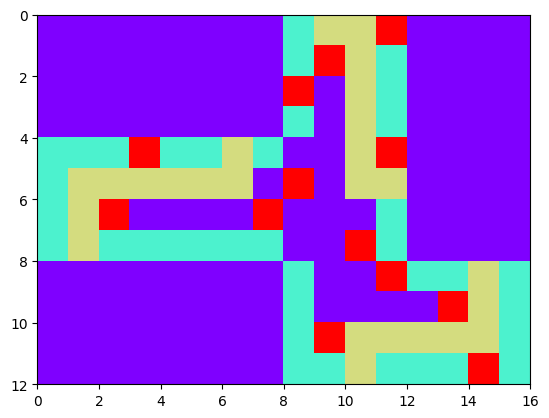

In [7]:
# TODO make the colors nicer, although it looks decent when using the non-example input file

# the evals are used to avoid parsing the string
maze_map_to_plot = maze_map.copy()
# maze_map_to_plot[:] *= 0
for wrap_point in wrap_points_correspondences_col_right.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_down.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_col_left.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_up.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for blocked_cell in blocked_paths:
    maze_map_to_plot[tuple(blocked_cell)] = 15
    
plt.imshow(maze_map_to_plot, cmap="rainbow", extent=[0,n_cols,n_rows,0]); # it is more practical to use a imshow than to show text, as the input that is not from the example is really long. It would be nice to have the text file scaled and displayed